<div style="background:linear-gradient(135deg,#1565C0 0%,#6A1B9A 100%);color:#ffffff;padding:34px 30px;border-radius:16px;margin:4px 0;box-shadow:0 6px 18px rgba(106,27,154,0.35);"><h1 style="margin:0;font-size:32px;color:#ffffff;">🤖 Grounded — Citation-Enforced RAG Assistant for RBI Compliance</h1><p style="margin:10px 0 0 0;font-size:17px;color:#E3F2FD;">A production-grade, fully-offline Agentic RAG system that answers banking-compliance questions over real RBI Master Directions — with page-level citations, and the discipline to say &ldquo;I don&rsquo;t know&rdquo; rather than hallucinate.</p></div>

<div style="background:#FAFAFA;border-left:6px solid #BDBDBD;color:#212121;padding:16px 20px;border-radius:10px;margin:6px 0;font-size:15px;line-height:1.6;"><b>Author:</b> Swagata Bhowmik &nbsp;|&nbsp; MSc Data Science, NMIMS Mumbai<br><b>Domain:</b> Banking / Financial Regulatory Compliance<br><b>Golden rule of this project:</b> real public data only, no fabrication — every result is defensible line-by-line.</div>

<div style="background:linear-gradient(90deg,#1565C0 0%,#7B1FA2 100%);color:#ffffff;padding:16px 22px;border-radius:12px;margin:18px 0 6px 0;"><h2 style="margin:0;color:#ffffff;font-size:24px;">0. &nbsp;The story: what we are building and why it matters</h2></div>

<div style="background:#F3E5F5;border-left:6px solid #8E24AA;color:#4A148C;padding:16px 20px;border-radius:10px;margin:6px 0;font-size:15px;line-height:1.6;"><b>🧠 Concept &amp; theory:</b><br><b>RAG</b> = <i>Retrieval-Augmented Generation</i>. Instead of asking a language model to answer from memory (where it can confidently invent facts — a &ldquo;hallucination&rdquo;), we first <b>retrieve</b> the most relevant real passages from a trusted document set, then ask the model to answer <b>using only those passages</b>, and to <b>cite</b> them. The answer becomes <i>grounded</i> in evidence you can verify.</div>

<div style="background:#F3E5F5;border-left:6px solid #8E24AA;color:#4A148C;padding:16px 20px;border-radius:10px;margin:6px 0;font-size:15px;line-height:1.6;"><b>🧠 Concept &amp; theory:</b><br><b>Agentic RAG</b> adds a decision-maker on top. A plain RAG pipeline always follows the same fixed path (retrieve → answer). An <b>agent</b> can instead <i>decide</i>: should I retrieve? is the evidence strong enough to answer? should I decline? This is what lets our system <b>refuse to answer when the documents don&rsquo;t support one</b> — the single most important trait for a compliance tool, where a confident wrong answer is worse than &ldquo;not found&rdquo;.</div>

<div style="background:#FAFAFA;border-left:6px solid #BDBDBD;color:#212121;padding:16px 20px;border-radius:10px;margin:6px 0;font-size:15px;line-height:1.6;"><b>🎯 The business problem.</b> Bank &amp; NBFC compliance teams must answer precise questions against dense RBI regulation (&ldquo;What is the beneficial-owner threshold for a trust under KYC rules?&rdquo;). Getting it wrong has real regulatory cost. We build an assistant that answers <i>with the exact source page</i>, and declines when the corpus lacks the answer.</div>

<div style="background:#E8F5E9;border-left:6px solid #2E7D32;color:#1B5E20;padding:16px 20px;border-radius:10px;margin:6px 0;font-size:15px;line-height:1.6;"><b>✅ What the output means (insight):</b><br>By the end of this notebook we will have, end-to-end and fully offline at zero API cost: (1) a validated corpus of real RBI Master Directions, (2) a chunk → embed → store → retrieve → <b>cite</b> pipeline, (3) hybrid retrieval (keyword + semantic) with cross-encoder re-ranking, (4) a LangGraph agent that enforces citations and declines on weak evidence, and (5) an evaluation layer: a hand-verified golden question set, NLI-based faithfulness scoring, and a CI quality gate.</div>

<h3 style="color:#1565C0;border-bottom:3px solid #90CAF9;padding-bottom:6px;margin:18px 0 8px 0;">🗺️ Notebook roadmap</h3>

<div style="background:#FAFAFA;border-left:6px solid #BDBDBD;color:#212121;padding:16px 20px;border-radius:10px;margin:6px 0;font-size:15px;line-height:1.6;"><b>Phase 1 — Fundamentals</b><br>1. Environment &amp; reproducibility &nbsp;·&nbsp; 2. The corpus (source, why, honest limits) &nbsp;·&nbsp; 3. Data profiling &amp; validation &nbsp;·&nbsp; 4. Chunking &nbsp;·&nbsp; 5. Embeddings &nbsp;·&nbsp; 6. Vector store (ChromaDB) &nbsp;·&nbsp; 7. Retrieve &amp; cite<br><br><b>Phase 2 — Production quality</b><br>8. Hybrid retrieval (BM25 + semantic) &nbsp;·&nbsp; 9. Cross-encoder re-ranking &nbsp;·&nbsp; 10. Citation enforcement &amp; refusal<br><br><b>Phase 3 — Agentic &amp; shippable</b><br>11. LangGraph agent &nbsp;·&nbsp; 12. Golden evaluation set &nbsp;·&nbsp; 13. NLI faithfulness scoring &nbsp;·&nbsp; 14. CI quality gate</div>

<div style="background:linear-gradient(90deg,#1565C0 0%,#7B1FA2 100%);color:#ffffff;padding:16px 22px;border-radius:12px;margin:18px 0 6px 0;"><h2 style="margin:0;color:#ffffff;font-size:24px;">1. &nbsp;Environment & reproducibility</h2></div>

<div style="background:#F3E5F5;border-left:6px solid #8E24AA;color:#4A148C;padding:16px 20px;border-radius:10px;margin:6px 0;font-size:15px;line-height:1.6;"><b>🧠 Concept &amp; theory:</b><br>A <b>conda environment</b> is an isolated, named box holding one specific Python version plus this project&rsquo;s libraries — separate from every other project on the machine. Why it matters: <b>reproducibility</b> (anyone can rebuild the exact setup) and <b>safety</b> (if something breaks, we rebuild the one box without touching anything else). This project lives in an env named <code>grounded-rag</code> running <b>Python 3.11</b> — chosen deliberately because every RAG/ML library we need ships stable installers for it.</div>

<div style="background:#ECEFF1;border-left:6px solid #607D8B;color:#263238;padding:16px 20px;border-radius:10px;margin:6px 0;font-size:15px;line-height:1.6;"><b>▶️ What this cell does (before running):</b><br>Print the Python version and executable path, so the notebook itself records exactly which interpreter produced every result below.</div>

In [1]:
import sys, platform
print('Python version :', sys.version.split()[0])
print('Executable     :', sys.executable)
print('Platform       :', platform.platform())

Python version : 3.11.15
Executable     : D:\grounded-rag-env\python.exe
Platform       : Windows-10-10.0.26200-SP0


<div style="background:#E8F5E9;border-left:6px solid #2E7D32;color:#1B5E20;padding:16px 20px;border-radius:10px;margin:6px 0;font-size:15px;line-height:1.6;"><b>✅ What the output means (insight):</b><br>The executable path should point inside <code>...\envs\grounded-rag\</code> and the version should read <b>3.11.x</b>. If it doesn&rsquo;t, the wrong kernel is selected — switch the kernel to <b>&ldquo;Python (grounded-rag)&rdquo;</b> (top-right in Jupyter) before continuing.</div>

<div style="background:linear-gradient(90deg,#1565C0 0%,#7B1FA2 100%);color:#ffffff;padding:16px 22px;border-radius:12px;margin:18px 0 6px 0;"><h2 style="margin:0;color:#ffffff;font-size:24px;">2. &nbsp;The corpus — real RBI Master Directions</h2></div>

<div style="background:#FAFAFA;border-left:6px solid #BDBDBD;color:#212121;padding:16px 20px;border-radius:10px;margin:6px 0;font-size:15px;line-height:1.6;"><b>🗂️ Source:</b> Official Reserve Bank of India website (rbi.org.in), downloaded directly as published PDFs.<br><b>Theme:</b> <i>Lending, Credit &amp; Customer Protection (Banks &amp; NBFCs)</i> — a deliberately <b>coherent</b> cluster, not random documents.</div>

<div style="background:#F3E5F5;border-left:6px solid #8E24AA;color:#4A148C;padding:16px 20px;border-radius:10px;margin:6px 0;font-size:15px;line-height:1.6;"><b>🧠 Concept &amp; theory:</b><br><b>Why this specific theme?</b> These documents genuinely <b>cross-reference each other</b> (KYC feeds lending; digital-lending rules reference NBFC regulation) and are dense with <b>exact clause numbers and defined terms</b>. That is precisely what justifies <b>hybrid retrieval</b> later: a user searching for an exact clause number needs keyword search, where pure &ldquo;meaning-based&rdquo; semantic search is weak. The corpus is chosen to make the hard techniques <i>necessary</i>, not decorative.</div>

<div style="background:#FFF3E0;border-left:6px solid #EF6C00;color:#E65100;padding:16px 20px;border-radius:10px;margin:6px 0;font-size:15px;line-height:1.6;"><b>⚠️ Honest note / gotcha:</b><br><b>Honest limitations of this corpus.</b> (1) It is a <i>focused slice</i> of RBI regulation (10 documents), not all of it — the assistant is only knowledgeable within this slice, and <i>should decline outside it</i>. (2) Regulations get amended; some sections are marked &ldquo;Withdrawn/Deleted&rdquo; — our citations point to the document <i>as downloaded</i> on a fixed date. (3) This is a portfolio system, <b>not legal advice</b>.</div>

<div style="background:#ECEFF1;border-left:6px solid #607D8B;color:#263238;padding:16px 20px;border-radius:10px;margin:6px 0;font-size:15px;line-height:1.6;"><b>▶️ What this cell does (before running):</b><br>List the corpus folder and show each PDF with its size. A healthy regulatory PDF is hundreds of KB to a few MB; a 0–2 KB file would signal a failed download.</div>

In [2]:
from pathlib import Path
import pandas as pd

CORPUS_DIR = Path('..') / 'regulatory_corpus'   # notebook lives in notebooks/
pdfs = sorted(CORPUS_DIR.glob('*.pdf'))
sizes = [{'file': p.name, 'size_KB': round(p.stat().st_size/1024, 1)} for p in pdfs]
pd.DataFrame(sizes)

,file,size_KB
0,01_KYC_Master_Direction_2016.pdf,885.6
1,02_Digital_Lending_Directions_2025.pdf,1094.5
2,03_NBFC_Scale_Based_Regulation_2023.pdf,4399.5
3,04_Credit_Debit_Card_Directions_2022.pdf,192.8
4,05_Microfinance_Loans_Framework_2022.pdf,250.1
5,06_Interest_Rate_on_Advances_2016.pdf,1023.5
6,07_Priority_Sector_Lending_Directions.pdf,830.6
7,08_Fraud_Risk_Management_Directions_2024.pdf,1145.8
8,09_Customer_Service_Master_Circular.pdf,1795.1
9,10_Outsourcing_Financial_Services_Directions.pdf,169.5


<div style="background:#E8F5E9;border-left:6px solid #2E7D32;color:#1B5E20;padding:16px 20px;border-radius:10px;margin:6px 0;font-size:15px;line-height:1.6;"><b>✅ What the output means (insight):</b><br>Ten PDFs, each a sensible size (≈170 KB to ≈4.4 MB). None are empty or truncated. File size only proves the <i>download</i> succeeded, though — it says nothing about whether the <i>text</i> is machine-readable. That is the job of Section 3.</div>

<div style="background:linear-gradient(90deg,#1565C0 0%,#7B1FA2 100%);color:#ffffff;padding:16px 22px;border-radius:12px;margin:18px 0 6px 0;"><h2 style="margin:0;color:#ffffff;font-size:24px;">3. &nbsp;Data profiling & validation — is this text even usable?</h2></div>

<div style="background:#F3E5F5;border-left:6px solid #8E24AA;color:#4A148C;padding:16px 20px;border-radius:10px;margin:6px 0;font-size:15px;line-height:1.6;"><b>🧠 Concept &amp; theory:</b><br>A PDF can store text in two very different ways. A <b>born-digital</b> PDF holds real selectable characters we can extract cleanly. A <b>scanned</b> PDF is really just <i>photos of pages</i> — it has ~0 extractable characters and would need OCR (optical character recognition). If we skipped this check and a scanned file slipped in, it would contribute <b>zero real text</b> yet still look fine by file size — silently poisoning every downstream answer. Hence: profile first, build second.</div>

<div style="background:#F3E5F5;border-left:6px solid #8E24AA;color:#4A148C;padding:16px 20px;border-radius:10px;margin:6px 0;font-size:15px;line-height:1.6;"><b>🧠 Concept &amp; theory:</b><br>We use two libraries. <b>PyMuPDF</b> (imported as <code>fitz</code>) extracts text <i>page by page</i> — essential because our citations are <b>page-level</b>. <b>pdfplumber</b> exposes each word&rsquo;s x/y position on the page, which we use for a <b>multi-column heuristic</b> (two-column layouts can scramble reading order). The profiler flags a page as &ldquo;low-text&rdquo; if it holds &lt; 100 characters — a hint it might be a scanned or blank page worth inspecting.</div>

<div style="background:#ECEFF1;border-left:6px solid #607D8B;color:#263238;padding:16px 20px;border-radius:10px;margin:6px 0;font-size:15px;line-height:1.6;"><b>▶️ What this cell does (before running):</b><br>Run the reusable <code>profile_corpus</code> function (kept in <code>src/corpus_profiler.py</code>) over all 10 PDFs. For each file it reports page count, total characters, average characters/page (text density), count of low-text pages, a multi-column flag, and embedded PDF metadata.</div>

In [3]:
import sys
sys.path.append('../src')          # make src/ importable from notebooks/
from corpus_profiler import profile_corpus

profile_df = profile_corpus(str(CORPUS_DIR))
profile_df

,file,pages,total_chars,avg_chars_per_page,low_text_pages,multicolumn,pdf_title,created
0,01_KYC_Master_Direction_2016.pdf,107,239021,2233.8,0,True,,D:20250814220706
1,02_Digital_Lending_Directions_2025.pdf,24,43875,1828.1,0,True,,D:20250509125649
2,03_NBFC_Scale_Based_Regulation_2023.pdf,330,615663,1865.6,3,True,,D:20250922123047
3,04_Credit_Debit_Card_Directions_2022.pdf,7,13998,1999.7,0,True,,D:20240307175943
4,05_Microfinance_Loans_Framework_2022.pdf,6,11848,1974.7,0,True,,D:20250131160412
5,06_Interest_Rate_on_Advances_2016.pdf,20,32298,1614.9,0,True,,D:20251001214433
6,07_Priority_Sector_Lending_Directions.pdf,52,93512,1798.3,0,False,,D:20260119210259
7,08_Fraud_Risk_Management_Directions_2024.pdf,20,43724,2186.2,0,True,,D:20240715161925
8,09_Customer_Service_Master_Circular.pdf,141,278835,1977.6,0,False,MASTER CIRCULAR ON CUSTOMER SERVICE,D:20140715192912
9,10_Outsourcing_Financial_Services_Directions.pdf,13,31502,2423.2,0,True,,D:20171109163740


<div style="background:#E8F5E9;border-left:6px solid #2E7D32;color:#1B5E20;padding:16px 20px;border-radius:10px;margin:6px 0;font-size:15px;line-height:1.6;"><b>✅ What the output means (insight):</b><br>Real result across the corpus: <b>720 pages</b> and <b>~1.40 million characters</b> of extractable text. Every document shows a healthy density of ~1,600–2,400 characters/page — meaning <b>zero scanned/image-only files</b>. The text is genuinely machine-readable, so no OCR step is required.</div>

<div style="background:#FFF3E0;border-left:6px solid #EF6C00;color:#E65100;padding:16px 20px;border-radius:10px;margin:6px 0;font-size:15px;line-height:1.6;"><b>⚠️ Honest note / gotcha:</b><br>Two things looked odd, so we investigated both (never trust a flag blindly): <br>• <b>8 of 10 flagged &ldquo;multi-column&rdquo;.</b> Inspecting the actual extracted text showed clean top-to-bottom reading order — the flag is a <b>false positive</b>, tripped by left-margin clause numbering (a., b., c.). No real problem. <br>• <b>3 low-text pages</b> (all in the NBFC document) turned out to be section-divider pages marked <i>&ldquo;Withdrawn&rdquo;/&ldquo;Deleted&rdquo;</i> — legitimate structure, not failed extraction.</div>

<div style="background:#ECEFF1;border-left:6px solid #607D8B;color:#263238;padding:16px 20px;border-radius:10px;margin:6px 0;font-size:15px;line-height:1.6;"><b>▶️ What this cell does (before running):</b><br>Confirm the multi-column flag is a false positive by printing a real page&rsquo;s extracted text and reading its order with our own eyes — the &ldquo;show real examples, not just summary numbers&rdquo; rule.</div>

In [4]:
import fitz
doc = fitz.open(str(CORPUS_DIR / '01_KYC_Master_Direction_2016.pdf'))
print(doc[5].get_text('text')[:1200])
doc.close()

 
 
6 
 
Explanation - For the purpose of this sub-clause, “control” shall include the 
right to control the management or policy decision. 
c. Where the customer is an unincorporated association or body of 
individuals, the beneficial owner is the natural person(s), who, whether acting 
alone or together, or through one or more juridical person, has/have ownership 
of/entitlement to more than 15 percent of the property or capital or profits of 
the unincorporated association or body of individuals.  
Explanation: Term ‘body of individuals’ includes societies. Where no natural 
person is identified under (a), (b) or (c) above, the beneficial owner is the 
relevant natural person who holds the position of senior managing official. 
d. 9Where the customer is a trust, the identification of beneficial owner(s) shall 
include identification of the author of the trust, the trustee, the beneficiaries 
with 10 percent or more interest in the trust and any other natural person 
exercising ultim

<div style="background:#E8F5E9;border-left:6px solid #2E7D32;color:#1B5E20;padding:16px 20px;border-radius:10px;margin:6px 0;font-size:15px;line-height:1.6;"><b>✅ What the output means (insight):</b><br>The passage reads in correct sequence — numbered/lettered clauses (a, b, c, d, v) flow top-to-bottom exactly as in the source PDF. Reading order is intact, so the multi-column flag can be safely ignored for these documents.</div>

<div style="background:#E0F2F1;border-left:6px solid #00897B;color:#004D40;padding:16px 20px;border-radius:10px;margin:6px 0;font-size:15px;line-height:1.6;"><b>🎯 Interview prep:</b><br><b>Q: &ldquo;Why profile the PDFs before building the RAG pipeline?&rdquo;</b><br>A: Because file size proves a download finished, not that the text is usable. A scanned PDF has ~0 extractable characters and would silently inject empty context into every answer. Profiling catches scanned files, broken extraction, and layout issues (multi-column, tables) <i>before</i> they corrupt retrieval — and it gives an honest baseline (720 pages, 1.4M chars) I can defend.</div>

<div style="background:#E8F5E9;border-left:6px solid #2E7D32;color:#1B5E20;padding:16px 20px;border-radius:10px;margin:6px 0;font-size:15px;line-height:1.6;"><b>✅ What the output means (insight):</b><br><b>Section 3 verdict:</b> the corpus is real, current, fully machine-readable, and safe to build on. ✅ Next: Section 4 — chunking this 1.4M-character corpus into retrievable, page-tagged pieces.</div>

<div style="background:linear-gradient(90deg,#1565C0 0%,#7B1FA2 100%);color:#ffffff;padding:16px 22px;border-radius:12px;margin:18px 0 6px 0;"><h2 style="margin:0;color:#ffffff;font-size:24px;">4. &nbsp;Chunking — splitting the corpus for retrieval</h2></div>

<h3 style="color:#1565C0;border-bottom:3px solid #90CAF9;padding-bottom:6px;margin:18px 0 8px 0;">🗄️ A quick engineering note: where the heavy files live</h3>

<div style="background:#FFF3E0;border-left:6px solid #EF6C00;color:#E65100;padding:16px 20px;border-radius:10px;margin:6px 0;font-size:15px;line-height:1.6;"><b>⚠️ Honest note / gotcha:</b><br>This machine&rsquo;s <b>C: drive is nearly full</b> while <b>D: has ~620 GB free</b>. PyTorch alone unpacks to &gt;1 GB, AI models add hundreds of MB, and a local LLM adds several GB. So the whole project — the Python environment, the model cache, the local-LLM store, and the vector database — was deliberately placed on <b>D:</b>. The cell below points the ML libraries at D: <i>before</i> they are imported. This is real engineering judgement, not an afterthought: it keeps the OS drive healthy and the project reproducible.</div>

<div style="background:#ECEFF1;border-left:6px solid #607D8B;color:#263238;padding:16px 20px;border-radius:10px;margin:6px 0;font-size:15px;line-height:1.6;"><b>▶️ What this cell does (before running):</b><br>Register <code>config/</code> and <code>src/</code> on the import path, then call <code>project_paths.apply_env()</code> to create the D: cache folders and set the environment variables (<code>HF_HOME</code> etc.) that control where models download. This must run <b>before</b> any transformers/sentence-transformers import.</div>

In [5]:
import sys
sys.path.append('../config')
sys.path.append('../src')
import project_paths

paths = project_paths.apply_env()   # point model caches at D: BEFORE model imports
paths

{'HF_HOME': 'D:\\grounded_rag_cache\\huggingface',
 'OLLAMA_MODELS': 'D:\\grounded_rag_cache\\ollama',
 'CHROMA_DIR': 'D:\\grounded_rag_cache\\chroma_store',
 'CORPUS_DIR': 'C:\\Users\\Lenovo\\Downloads\\Project-4\\regulatory_corpus'}

<div style="background:#E8F5E9;border-left:6px solid #2E7D32;color:#1B5E20;padding:16px 20px;border-radius:10px;margin:6px 0;font-size:15px;line-height:1.6;"><b>✅ What the output means (insight):</b><br>The returned dictionary confirms models will cache under <code>D:\grounded_rag_cache\huggingface</code>, the local LLM under <code>...\ollama</code>, and the vector store under <code>...\chroma_store</code> — all on the roomy drive. The corpus itself stays in the repo.</div>

<h3 style="color:#1565C0;border-bottom:3px solid #90CAF9;padding-bottom:6px;margin:18px 0 8px 0;">🧠 What chunking is, and the knobs that control it</h3>

<div style="background:#F3E5F5;border-left:6px solid #8E24AA;color:#4A148C;padding:16px 20px;border-radius:10px;margin:6px 0;font-size:15px;line-height:1.6;"><b>🧠 Concept &amp; theory:</b><br><b>Chunking</b> = cutting long documents into small passages so that (a) each passage fits inside the embedding model&rsquo;s input limit, and (b) retrieval returns a tight, focused piece of evidence rather than a whole 300-page document. The two knobs:<br>&bull; <b>chunk size</b> (in tokens) — bigger = more context per chunk but less precise retrieval and risk of hitting the model&rsquo;s limit; smaller = sharper retrieval but more fragments and lost context.<br>&bull; <b>overlap</b> — how many tokens consecutive chunks share, so an idea landing on a boundary is not split away from its context.</div>

<div style="background:#F3E5F5;border-left:6px solid #8E24AA;color:#4A148C;padding:16px 20px;border-radius:10px;margin:6px 0;font-size:15px;line-height:1.6;"><b>🧠 Concept &amp; theory:</b><br><b>Why measure size in &ldquo;tokens&rdquo;, and whose tokens?</b> A <b>token</b> is the sub-word unit a model actually reads (&ldquo;identification&rdquo; may be 3–4 tokens). Our embedding model is <b>BAAI/bge-small-en-v1.5</b>, whose <b>hard limit is 512 tokens</b> — anything past that is silently dropped. So we count chunk length with <i>that model&rsquo;s own tokenizer</i>, guaranteeing no chunk is ever truncated at embedding time. We also chunk <b>page by page</b> and tag each chunk with its exact page number — the foundation of page-level citations.</div>

<div style="background:#ECEFF1;border-left:6px solid #607D8B;color:#263238;padding:16px 20px;border-radius:10px;margin:6px 0;font-size:15px;line-height:1.6;"><b>▶️ What this cell does (before running):</b><br>Load the bge-small tokenizer (a small one-time download to the D: cache) and run a <b>chunk-size experiment</b>: try three settings — (256/40), (384/64), (480/80) tokens — and compare chunk count and token statistics. The &ldquo;try more than one option, then justify&rdquo; rule in action.</div>

In [6]:
from document_chunker import get_tokenizer, experiment_chunk_sizes, chunk_corpus

tokenizer = get_tokenizer()          # bge-small tokenizer (caches to D:)
experiment_df = experiment_chunk_sizes(
    str(project_paths.CORPUS_DIR),
    configs=[(256, 40), (384, 64), (480, 80)],
    tokenizer=tokenizer,
)
experiment_df

D:\grounded-rag-env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


,chunk_tokens,overlap_tokens,n_chunks,avg_tokens,median_tokens,max_tokens,over_512
0,256,40,1649,205.3,241,256,0
1,384,64,1252,270.2,333,384,0
2,480,80,947,342.7,401,480,0


<div style="background:#E8F5E9;border-left:6px solid #2E7D32;color:#1B5E20;padding:16px 20px;border-radius:10px;margin:6px 0;font-size:15px;line-height:1.6;"><b>✅ What the output means (insight):</b><br>Real result: <b>256/40 → 1,649 chunks</b> (avg 205 tok), <b>384/64 → 1,252 chunks</b> (avg 270, median 333 tok), <b>480/80 → 947 chunks</b> (avg 343 tok). Crucially, the <code>over_512</code> column is <b>0 for every setting</b> — no chunk would be truncated by the embedder. The trade-off is visible: smaller chunks multiply fragments; larger chunks pack more context but sit closer to the 512 ceiling.</div>

<div style="background:#F3E5F5;border-left:6px solid #8E24AA;color:#4A148C;padding:16px 20px;border-radius:10px;margin:6px 0;font-size:15px;line-height:1.6;"><b>🧠 Concept &amp; theory:</b><br><b>Decision — we pick 384 tokens with 64 overlap.</b> It is the balanced middle: a healthy median of ~333 tokens per chunk (real regulatory context, not scraps), comfortable headroom below the 512 limit, and a sensible 1,252 chunks — enough granularity for precise retrieval without over-fragmenting. The 64-token (~17%) overlap protects ideas sitting on chunk boundaries.</div>

<div style="background:#ECEFF1;border-left:6px solid #607D8B;color:#263238;padding:16px 20px;border-radius:10px;margin:6px 0;font-size:15px;line-height:1.6;"><b>▶️ What this cell does (before running):</b><br>Build the final chunk set with the chosen 384/64 config and inspect a real chunk — its id, source document, page number, token count, and text.</div>

In [7]:
chunks = chunk_corpus(str(project_paths.CORPUS_DIR), 384, 64, tokenizer=tokenizer)
print(f'Total chunks: {len(chunks)}')

example = chunks[50]
print('chunk_id   :', example['chunk_id'])
print('source_file:', example['source_file'], '| page', example['page'])
print('token_count:', example['token_count'])
print('-' * 70)
print(example['text'][:400])

Total chunks: 1252
chunk_id   : 01_KYC_Master_Direction_2016__p22__c50
source_file: 01_KYC_Master_Direction_2016.pdf | page 22
token_count: 378
----------------------------------------------------------------------
22 
 
Chapter V 
Customer Identification Procedure (CIP) 
13. REs shall undertake identification of customers in the following cases: 
(a) Commencement of an account-based relationship with the customer. 
(b) 51Carrying out any international money transfer operations for a person who is not 
an account holder of the RE.  
(c) When there is a doubt about the authenticity or adequacy of the customer


<div style="background:#E8F5E9;border-left:6px solid #2E7D32;color:#1B5E20;padding:16px 20px;border-radius:10px;margin:6px 0;font-size:15px;line-height:1.6;"><b>✅ What the output means (insight):</b><br>A real chunk (from the KYC Master Direction, <b>page 22</b>, ~378 tokens) captures a complete, self-contained idea — the opening of <i>Chapter V, Customer Identification Procedure</i>, listing exactly when Regulated Entities must identify a customer. Note the <code>chunk_id</code> embeds the source and page (<code>..._p22_...</code>): that provenance is what a citation will later point to.</div>

<div style="background:#ECEFF1;border-left:6px solid #607D8B;color:#263238;padding:16px 20px;border-radius:10px;margin:6px 0;font-size:15px;line-height:1.6;"><b>▶️ What this cell does (before running):</b><br>Visualize the chunk set two ways: (1) the distribution of tokens-per-chunk (are we using the budget well?), and (2) chunks per document (which regulations dominate the index?). Each chart gets a one-line reading.</div>

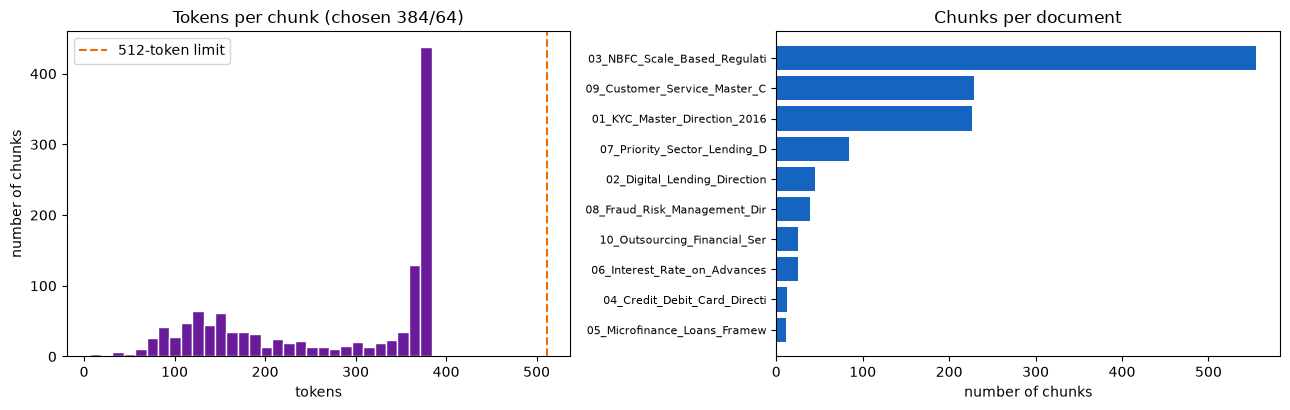

In [8]:
import matplotlib.pyplot as plt
import pandas as pd

cdf = pd.DataFrame(chunks)
fig, ax = plt.subplots(1, 2, figsize=(13, 4.2))

ax[0].hist(cdf['token_count'], bins=30, color='#6A1B9A', edgecolor='white')
ax[0].axvline(512, color='#EF6C00', linestyle='--', label='512-token limit')
ax[0].set_title('Tokens per chunk (chosen 384/64)')
ax[0].set_xlabel('tokens'); ax[0].set_ylabel('number of chunks'); ax[0].legend()

by_doc = cdf['source_file'].value_counts().sort_values()
ax[1].barh(range(len(by_doc)), by_doc.values, color='#1565C0')
ax[1].set_yticks(range(len(by_doc)))
ax[1].set_yticklabels([n[:28] for n in by_doc.index], fontsize=8)
ax[1].set_title('Chunks per document')
ax[1].set_xlabel('number of chunks')

plt.tight_layout(); plt.show()

<div style="background:#E8F5E9;border-left:6px solid #2E7D32;color:#1B5E20;padding:16px 20px;border-radius:10px;margin:6px 0;font-size:15px;line-height:1.6;"><b>✅ What the output means (insight):</b><br>Left: the token distribution clusters below ~384 and stays well clear of the orange 512-token limit — the budget is used efficiently with no truncation risk. Right: the largest, densest regulations (the NBFC Scale-Based Regulation and the Customer Service circular) contribute the most chunks, exactly as expected from their page counts in Section 3 — a good sanity check that chunking scales with real content.</div>

<div style="background:#E0F2F1;border-left:6px solid #00897B;color:#004D40;padding:16px 20px;border-radius:10px;margin:6px 0;font-size:15px;line-height:1.6;"><b>🎯 Interview prep:</b><br><b>Q: &ldquo;How did you choose your chunk size?&rdquo;</b><br>A: Empirically, not by guessing. I fixed the embedding model first (bge-small, 512-token limit), measured chunk length in <i>its</i> tokenizer, and compared three settings on the real corpus. All avoided truncation, so I chose 384/64 for the best balance of context vs. retrieval precision — ~1,250 chunks with a median of ~330 tokens. I can defend the number with the experiment table, not a rule of thumb.</div>

<div style="background:#E8F5E9;border-left:6px solid #2E7D32;color:#1B5E20;padding:16px 20px;border-radius:10px;margin:6px 0;font-size:15px;line-height:1.6;"><b>✅ What the output means (insight):</b><br><b>Section 4 verdict:</b> the corpus is now <b>1,252 page-tagged chunks</b>, each within the embedder&rsquo;s limit and carrying exact source+page provenance. ✅ Next: Section 5 — turning these chunks into embeddings (vectors) with bge-small.</div>

<div style="background:linear-gradient(90deg,#1565C0 0%,#7B1FA2 100%);color:#ffffff;padding:16px 22px;border-radius:12px;margin:18px 0 6px 0;"><h2 style="margin:0;color:#ffffff;font-size:24px;">5. &nbsp;Embeddings — turning chunks into meaning-vectors</h2></div>

<div style="background:#F3E5F5;border-left:6px solid #8E24AA;color:#4A148C;padding:16px 20px;border-radius:10px;margin:6px 0;font-size:15px;line-height:1.6;"><b>🧠 Concept &amp; theory:</b><br><b>An embedding</b> is a fixed-length list of numbers that captures the <i>meaning</i> of a piece of text. The trick: texts with similar meaning get vectors pointing in similar directions, so we can find relevant passages by comparing vector <i>direction</i> (<b>cosine similarity</b>) rather than matching exact words. This is what lets a search for &ldquo;who really owns a company&rdquo; find a passage about &ldquo;beneficial ownership&rdquo; even with no shared keywords.</div>

<div style="background:#F3E5F5;border-left:6px solid #8E24AA;color:#4A148C;padding:16px 20px;border-radius:10px;margin:6px 0;font-size:15px;line-height:1.6;"><b>🧠 Concept &amp; theory:</b><br><b>Our model: BAAI/bge-small-en-v1.5 — what it actually is and contains.</b><br>&bull; <b>Type:</b> a BERT-style transformer fine-tuned specifically for retrieval.<br>&bull; <b>Output dimension:</b> <b>384</b> numbers per text.<br>&bull; <b>Max input:</b> <b>512 tokens</b> (the exact reason we capped chunks under 512).<br>&bull; <b>Normalization:</b> vectors are L2-normalized, after which cosine similarity equals a simple dot product (fast).<br>&bull; <b>Query vs passage:</b> bge works best when a <i>search query</i> is prefixed with a short instruction (&ldquo;Represent this sentence for searching relevant passages:&rdquo;) while stored <i>passages</i> are embedded as-is. We honour both.<br>&bull; <b>Cost/where it runs:</b> small enough to run on <b>CPU</b>, fully offline, free — the whole corpus is embedded locally with no API calls.</div>

<div style="background:#ECEFF1;border-left:6px solid #607D8B;color:#263238;padding:16px 20px;border-radius:10px;margin:6px 0;font-size:15px;line-height:1.6;"><b>▶️ What this cell does (before running):</b><br>Load the embedding model onto the CPU. It is already cached on D: from setup, so this is fast. We confirm its output dimension is 384.</div>

In [9]:
from embedder import load_embedder, embed_passages, embed_query, cosine_sim, EMBED_DIM

embedder = load_embedder()          # bge-small on CPU, from the D: cache
print('Embedding model ready | output dimension =', EMBED_DIM)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 5770.53it/s]

Embedding model ready | output dimension = 384


<div style="background:#E8F5E9;border-left:6px solid #2E7D32;color:#1B5E20;padding:16px 20px;border-radius:10px;margin:6px 0;font-size:15px;line-height:1.6;"><b>✅ What the output means (insight):</b><br>The model is loaded and reports a <b>384-dimensional</b> output. Every chunk and every query will become a point in the same 384-dimensional &ldquo;meaning space&rdquo;.</div>

<h3 style="color:#1565C0;border-bottom:3px solid #90CAF9;padding-bottom:6px;margin:18px 0 8px 0;">🔬 Seeing semantic similarity actually work</h3>

<div style="background:#ECEFF1;border-left:6px solid #607D8B;color:#263238;padding:16px 20px;border-radius:10px;margin:6px 0;font-size:15px;line-height:1.6;"><b>▶️ What this cell does (before running):</b><br>A tiny, fast demonstration before we embed everything: take a real compliance question and three sentences — one nearly identical, one on the same topic, one unrelated — and measure the cosine similarity of the question to each. If embeddings capture meaning, the scores should rank in that order.</div>

In [10]:
samples = [
    'What is the beneficial owner threshold for a trust under KYC rules?',
    'For a trust, the beneficial owner includes persons with 10 percent interest.',
    'Priority sector lending targets for regional rural banks.',
]
sample_vecs = embed_passages(embedder, samples, show_progress=False)
q_vec = embed_query(embedder, samples[0])

for s, v in zip(samples, sample_vecs):
    print(f'{cosine_sim(q_vec, v):.3f}   {s}')

0.978   What is the beneficial owner threshold for a trust under KYC rules?
0.721   For a trust, the beneficial owner includes persons with 10 percent interest.
0.546   Priority sector lending targets for regional rural banks.


<div style="background:#E8F5E9;border-left:6px solid #2E7D32;color:#1B5E20;padding:16px 20px;border-radius:10px;margin:6px 0;font-size:15px;line-height:1.6;"><b>✅ What the output means (insight):</b><br>Real scores: <b>0.978</b> (near-identical restatement), <b>0.721</b> (same topic — the actual trust beneficial-owner rule), <b>0.546</b> (unrelated priority-sector text). The ranking is exactly right, and the gaps are meaningful — this is the core mechanism that will power retrieval. Higher score = more relevant.</div>

<h3 style="color:#1565C0;border-bottom:3px solid #90CAF9;padding-bottom:6px;margin:18px 0 8px 0;">⚙️ Embedding the full corpus</h3>

<div style="background:#FFF3E0;border-left:6px solid #EF6C00;color:#E65100;padding:16px 20px;border-radius:10px;margin:6px 0;font-size:15px;line-height:1.6;"><b>⚠️ Honest note / gotcha:</b><br><b>⏳ This is a &ldquo;long job&rdquo; — run it yourself in JupyterLab.</b> It embeds all <b>1,252 chunks</b> on the CPU and typically takes <b>~1–3 minutes</b> on this machine. A progress bar will appear. Per our working method, compute-heavy steps like this are run by you, live, rather than pre-baked — Kiro wrote and verified the code on a small sample first.</div>

<div style="background:#ECEFF1;border-left:6px solid #607D8B;color:#263238;padding:16px 20px;border-radius:10px;margin:6px 0;font-size:15px;line-height:1.6;"><b>▶️ What this cell does (before running):</b><br>Embed every chunk&rsquo;s text into a (1252 &times; 384) matrix of normalized vectors, then save it to the D: cache so it can be reused without re-embedding. The row order matches <code>chunks</code>, so row <i>i</i> is the vector for <code>chunks[i]</code>.</div>

In [11]:
import numpy as np
from pathlib import Path

chunk_texts = [c['text'] for c in chunks]
embeddings = embed_passages(embedder, chunk_texts, batch_size=32, show_progress=True)

print('Embeddings matrix shape:', embeddings.shape)   # expect (1252, 384)

emb_dir = Path(project_paths.CACHE_ROOT) / 'embeddings'
emb_dir.mkdir(parents=True, exist_ok=True)
np.save(emb_dir / 'corpus_embeddings.npy', embeddings)
print('Saved embeddings to', emb_dir / 'corpus_embeddings.npy')

Batches:   0%|          | 0/40 [00:00<?, ?it/s]

Batches:   2%|▎         | 1/40 [00:04<02:45,  4.24s/it]

Batches:   5%|▌         | 2/40 [00:08<02:43,  4.30s/it]

Batches:   8%|▊         | 3/40 [00:13<02:49,  4.59s/it]

Batches:  10%|█         | 4/40 [00:18<02:57,  4.93s/it]

...

Batches:  92%|█████████▎| 37/40 [03:11<00:15,  5.17s/it]

Batches:  95%|█████████▌| 38/40 [03:15<00:09,  4.90s/it]

Batches:  98%|█████████▊| 39/40 [03:19<00:04,  4.50s/it]

Batches: 100%|██████████| 40/40 [03:19<00:00,  4.98s/it]

Embeddings matrix shape: (1252, 384)
Saved embeddings to D:\grounded_rag_cache\embeddings\corpus_embeddings.npy


<div style="background:#E8F5E9;border-left:6px solid #2E7D32;color:#1B5E20;padding:16px 20px;border-radius:10px;margin:6px 0;font-size:15px;line-height:1.6;"><b>✅ What the output means (insight):</b><br>The result is a <b>(1252, 384)</b> matrix — one 384-number vector per chunk — saved to D: for reuse. Every regulation passage is now a point in meaning-space, ready to be indexed for fast similarity search in the next section.</div>

<div style="background:#E0F2F1;border-left:6px solid #00897B;color:#004D40;padding:16px 20px;border-radius:10px;margin:6px 0;font-size:15px;line-height:1.6;"><b>🎯 Interview prep:</b><br><b>Q: &ldquo;Why embeddings instead of keyword search?&rdquo;</b><br>A: Keyword search misses paraphrases — a user asking &ldquo;who really controls the company&rdquo; won&rsquo;t match text that says &ldquo;beneficial owner&rdquo;. Embeddings map meaning to geometry, so semantically similar text is retrievable even with zero shared words. (In Phase 2 we&rsquo;ll <i>add keyword/BM25 search back</i> as a complement, because exact clause numbers are a case where keywords beat semantics — that&rsquo;s the whole point of hybrid retrieval.)</div>

<div style="background:#E8F5E9;border-left:6px solid #2E7D32;color:#1B5E20;padding:16px 20px;border-radius:10px;margin:6px 0;font-size:15px;line-height:1.6;"><b>✅ What the output means (insight):</b><br><b>Section 5 verdict:</b> all 1,252 chunks are now 384-dimensional normalized vectors, validated by a working similarity demo. ✅ Next: Section 6 — storing these in <b>ChromaDB</b> so we can search them in milliseconds and retrieve with page citations.</div>

<div style="background:linear-gradient(90deg,#1565C0 0%,#7B1FA2 100%);color:#ffffff;padding:16px 22px;border-radius:12px;margin:18px 0 6px 0;"><h2 style="margin:0;color:#ffffff;font-size:24px;">6. &nbsp;ChromaDB — indexing vectors for cited retrieval</h2></div>

<div style="background:#F3E5F5;border-left:6px solid #8E24AA;color:#4A148C;padding:16px 20px;border-radius:10px;margin:6px 0;font-size:15px;line-height:1.6;"><b>🧠 Concept &amp; theory:</b><br><b>ChromaDB</b> is a small, open-source <b>vector database</b>. A normal database finds rows by exact values; a vector database finds items by <i>nearness in meaning space</i>. We hand it our 1,252 chunk vectors once; afterwards it answers &ldquo;which chunks are closest to this query?&rdquo; in milliseconds. It <b>persists to disk</b> (on D:), so the index survives a restart — no re-embedding needed.</div>

<div style="background:#F3E5F5;border-left:6px solid #8E24AA;color:#4A148C;padding:16px 20px;border-radius:10px;margin:6px 0;font-size:15px;line-height:1.6;"><b>🧠 Concept &amp; theory:</b><br><b>Two deliberate choices.</b> (1) We store the vectors <i>we</i> computed with bge-small rather than letting Chroma embed text itself — this guarantees a single, consistent embedding model across chunks <i>and</i> queries (a silent mismatch is a classic RAG bug). (2) We create the collection with <b>cosine</b> space; Chroma returns a <i>distance</i> (0 = identical), which we convert to an intuitive <b>similarity = 1 − distance</b> so higher always means more relevant.</div>

<div style="background:#ECEFF1;border-left:6px solid #607D8B;color:#263238;padding:16px 20px;border-radius:10px;margin:6px 0;font-size:15px;line-height:1.6;"><b>▶️ What this cell does (before running):</b><br>Open a persistent Chroma client on D:, then (re)build the <code>rbi_compliance</code> collection by adding all 1,252 chunks with their vectors and page-level metadata. Confirm the stored count is 1,252.</div>

In [12]:
from vector_store import get_client, build_collection, search

client = get_client(str(project_paths.CHROMA_DIR))
collection = build_collection(client, chunks, embeddings, rebuild=True)
print('Chunks indexed in ChromaDB:', collection.count())

Chunks indexed in ChromaDB: 1252


<div style="background:#E8F5E9;border-left:6px solid #2E7D32;color:#1B5E20;padding:16px 20px;border-radius:10px;margin:6px 0;font-size:15px;line-height:1.6;"><b>✅ What the output means (insight):</b><br>All <b>1,252</b> chunks are now indexed and persisted on D:. Each stored item carries its vector, its text, and its <code>source_file</code> + <code>page</code> — the metadata that turns a retrieval hit into a real citation.</div>

<div style="background:#ECEFF1;border-left:6px solid #607D8B;color:#263238;padding:16px 20px;border-radius:10px;margin:6px 0;font-size:15px;line-height:1.6;"><b>▶️ What this cell does (before running):</b><br>Define a small helper that renders retrieval results as colored cards: a green similarity badge, the blue citation (document + page), and a snippet of the passage. We reuse it for every query below.</div>

In [13]:
from IPython.display import HTML, display

def render_hits(query, hits):
    html = '<div style="font-family:sans-serif;">'
    html += ('<div style="background:linear-gradient(90deg,#1565C0,#6A1B9A);'
             'color:white;padding:10px 14px;border-radius:8px;margin:6px 0;">'
             f'<b>🔎 Query:</b> {query}</div>')
    for h in hits:
        html += ('<div style="border:1px solid #cfd8dc;border-left:5px solid #2E7D32;'
                 'border-radius:8px;padding:10px 14px;margin:6px 0;background:#FAFDF9;">'
                 f'<span style="background:#2E7D32;color:white;padding:2px 8px;'
                 f'border-radius:12px;font-size:12px;">similarity {h["similarity"]:.3f}</span> '
                 f'<span style="color:#1565C0;font-weight:bold;"> 📄 {h["source_file"]} — page {h["page"]}</span>'
                 f'<div style="margin-top:6px;color:#263238;font-size:14px;">{h["text"][:320].strip()}…</div>'
                 '</div>')
    html += '</div>'
    display(HTML(html))

def ask(query, k=3):
    hits = search(collection, embed_query(embedder, query), k=k)
    render_hits(query, hits)
    return hits

<h3 style="color:#1565C0;border-bottom:3px solid #90CAF9;padding-bottom:6px;margin:18px 0 8px 0;">🔎 First real cited retrieval</h3>

<div style="background:#ECEFF1;border-left:6px solid #607D8B;color:#263238;padding:16px 20px;border-radius:10px;margin:6px 0;font-size:15px;line-height:1.6;"><b>▶️ What this cell does (before running):</b><br>Ask a real KYC compliance question. Expect the top hits to come from the KYC Master Direction, each tagged with its exact page number.</div>

In [14]:
_ = ask("What is the beneficial owner threshold for a trust under KYC rules?")

<div style="background:#E8F5E9;border-left:6px solid #2E7D32;color:#1B5E20;padding:16px 20px;border-radius:10px;margin:6px 0;font-size:15px;line-height:1.6;"><b>✅ What the output means (insight):</b><br>The top passages are all from the <b>KYC Master Direction</b>: the strongest (similarity ≈ 0.737) is <b>page 38</b>, the exact clause on trustee disclosure for trusts; page 6 (the definition of &ldquo;control&rdquo;) and page 40 follow. This is the whole system in miniature — a question returns the precise passages <i>and the pages they live on</i>.</div>

<div style="background:#ECEFF1;border-left:6px solid #607D8B;color:#263238;padding:16px 20px;border-radius:10px;margin:6px 0;font-size:15px;line-height:1.6;"><b>▶️ What this cell does (before running):</b><br>A second, different-domain question — digital lending — to show retrieval routes to the right document, not just KYC.</div>

In [15]:
_ = ask("What must a digital lending app disclose to borrowers?")

<div style="background:#E8F5E9;border-left:6px solid #2E7D32;color:#1B5E20;padding:16px 20px;border-radius:10px;margin:6px 0;font-size:15px;line-height:1.6;"><b>✅ What the output means (insight):</b><br>Retrieval correctly jumps to the <b>Digital Lending Directions 2025</b>. The hit on <b>page 8</b> is exactly the operative clause — <i>&ldquo;Disclosures to borrowers … Key Fact Statement (KFS)&rdquo;</i> — the real answer, with its citation. A keyword search for the phrase &ldquo;digital lending app&rdquo; would not have found this as cleanly; meaning-based retrieval did.</div>

<h3 style="color:#1565C0;border-bottom:3px solid #90CAF9;padding-bottom:6px;margin:18px 0 8px 0;">🛑 The most important test: a question the corpus cannot answer</h3>

<div style="background:#F3E5F5;border-left:6px solid #8E24AA;color:#4A148C;padding:16px 20px;border-radius:10px;margin:6px 0;font-size:15px;line-height:1.6;"><b>🧠 Concept &amp; theory:</b><br><b>Why deliberately ask something absent?</b> A trustworthy compliance assistant must <i>refuse</i> when it has no real evidence, instead of inventing an answer. Retrieval always returns <i>something</i> (the nearest chunks), so the signal we rely on is <b>how weak the top similarity is</b>. If even the best match is poor, that is our cue to decline — the mechanism we formalize as <b>citation enforcement</b> in Phase 2.</div>

<div style="background:#ECEFF1;border-left:6px solid #607D8B;color:#263238;padding:16px 20px;border-radius:10px;margin:6px 0;font-size:15px;line-height:1.6;"><b>▶️ What this cell does (before running):</b><br>Ask an out-of-corpus question (a chocolate-cake recipe) and watch the similarity scores collapse compared with the real questions above.</div>

In [16]:
_ = ask("How is a recipe for chocolate cake prepared?")

<div style="background:#FFF3E0;border-left:6px solid #EF6C00;color:#E65100;padding:16px 20px;border-radius:10px;margin:6px 0;font-size:15px;line-height:1.6;"><b>⚠️ Honest note / gotcha:</b><br>The best match is only <b>~0.507</b>, and the returned passages are visibly irrelevant (cheque books, PAN) — versus <b>0.72–0.76</b> for genuine questions. That clear gap is gold: a similarity <b>threshold</b> can separate &ldquo;we have real evidence&rdquo; from &ldquo;decline&rdquo;. We will turn this observation into an enforced refusal rule in Phase 2 rather than ever hallucinating an answer.</div>

<div style="background:#E0F2F1;border-left:6px solid #00897B;color:#004D40;padding:16px 20px;border-radius:10px;margin:6px 0;font-size:15px;line-height:1.6;"><b>🎯 Interview prep:</b><br><b>Q: &ldquo;How do citations actually work in your RAG system?&rdquo;</b><br>A: Every chunk is stored with its source document and page number as metadata. When a query retrieves a chunk, that metadata travels with it, so the answer can point to the exact page the evidence came from. And because retrieval always returns <i>something</i>, I track the top similarity: a weak best-match (my out-of-corpus test scored ~0.51 vs ~0.74 for real questions) is the trigger to decline rather than fabricate.</div>

<div style="background:#E8F5E9;border-left:6px solid #2E7D32;color:#1B5E20;padding:16px 20px;border-radius:10px;margin:6px 0;font-size:15px;line-height:1.6;"><b>✅ What the output means (insight):</b><br><b>Section 6 verdict:</b> we have a working, persistent, <b>cited</b> retrieval engine — question → nearest passages → exact document &amp; page — plus clear evidence that similarity separates answerable from unanswerable questions. ✅ That closes <b>Phase 1</b>. Next, <b>Phase 2</b>: add keyword/BM25 search (hybrid retrieval), cross-encoder re-ranking, and formal citation enforcement.</div>

<div style="background:linear-gradient(135deg,#1565C0 0%,#6A1B9A 100%);color:#ffffff;padding:34px 30px;border-radius:16px;margin:4px 0;box-shadow:0 6px 18px rgba(106,27,154,0.35);"><h1 style="margin:0;font-size:32px;color:#ffffff;">⚙️ Phase 2 — Production-Quality Retrieval</h1><p style="margin:10px 0 0 0;font-size:17px;color:#E3F2FD;">Plain semantic search is a good start, but a compliance tool needs more: keyword precision for exact clause numbers, a sharper relevance re-ranker, and the discipline to decline when the evidence is weak.</p></div>

<div style="background:linear-gradient(90deg,#1565C0 0%,#7B1FA2 100%);color:#ffffff;padding:16px 22px;border-radius:12px;margin:18px 0 6px 0;"><h2 style="margin:0;color:#ffffff;font-size:24px;">7. &nbsp;Hybrid retrieval — keyword (BM25) + semantic</h2></div>

<div style="background:#F3E5F5;border-left:6px solid #8E24AA;color:#4A148C;padding:16px 20px;border-radius:10px;margin:6px 0;font-size:15px;line-height:1.6;"><b>🧠 Concept &amp; theory:</b><br><b>BM25</b> is the classic <b>keyword</b> search algorithm. It scores a passage by how often the query&rsquo;s words appear in it, dampened by how common each word is across the corpus (rare words count more) and adjusted for passage length. It is <b>excellent at exact tokens</b> — a regulation number like &ldquo;3.1&rdquo;, an acronym like &ldquo;KFS&rdquo;, a defined term — precisely where semantic search can drift.</div>

<div style="background:#F3E5F5;border-left:6px solid #8E24AA;color:#4A148C;padding:16px 20px;border-radius:10px;margin:6px 0;font-size:15px;line-height:1.6;"><b>🧠 Concept &amp; theory:</b><br><b>Why combine, and how (Reciprocal Rank Fusion).</b> Semantic search nails paraphrase; BM25 nails exact tokens. We run both and fuse their <i>rankings</i> with <b>RRF</b>: each passage scores <code>Σ 1/(k + rank)</code> across the two lists. RRF uses only ranks, not raw scores — so it sidesteps the fact that BM25 scores and cosine similarities live on completely different scales. Robust and parameter-light.</div>

<div style="background:#ECEFF1;border-left:6px solid #607D8B;color:#263238;padding:16px 20px;border-radius:10px;margin:6px 0;font-size:15px;line-height:1.6;"><b>▶️ What this cell does (before running):</b><br>Build the <code>HybridRetriever</code> over our 1,252 chunks. This constructs the BM25 keyword index and also loads the <b>cross-encoder re-ranker</b> (~80 MB, cached on D:) that Section 8 will use.</div>

In [17]:
from hybrid_retriever import HybridRetriever

retriever = HybridRetriever(chunks, embeddings, embedder)
print('Hybrid retriever ready: BM25 index +', len(chunks), 'chunks + cross-encoder loaded')

The Transformer `cache_dir` argument is deprecated. Please pass `cache_dir` via `model_kwargs`, `processor_kwargs`, and/or `config_kwargs` instead.


Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 105/105 [00:00<00:00, 5909.13it/s]

Hybrid retriever ready: BM25 index + 1252 chunks + cross-encoder loaded


<div style="background:#E8F5E9;border-left:6px solid #2E7D32;color:#1B5E20;padding:16px 20px;border-radius:10px;margin:6px 0;font-size:15px;line-height:1.6;"><b>✅ What the output means (insight):</b><br>The retriever now holds three tools: the BM25 keyword index, the semantic vectors from Section 5, and a cross-encoder for Section 8 — all local, all free.</div>

<div style="background:#ECEFF1;border-left:6px solid #607D8B;color:#263238;padding:16px 20px;border-radius:10px;margin:6px 0;font-size:15px;line-height:1.6;"><b>▶️ What this cell does (before running):</b><br>For one real query, compare the top-5 from <b>semantic-only</b>, <b>BM25-only</b>, and the <b>fused</b> ranking, as document+page lists. Watch how fusion blends both signals.</div>

In [18]:
def _show(idxs):
    return [f"{chunks[i]['source_file'][:22]} p.{chunks[i]['page']}" for i in idxs]

q = 'What must a digital lending app disclose to borrowers via KFS?'
print('SEMANTIC-only :', _show(retriever.semantic_rank(q, 5)))
print('BM25-only     :', _show(retriever.bm25_rank(q, 5)))
print('HYBRID (RRF)  :', _show(retriever.hybrid_candidates(q, top_each=50)[:5]))

SEMANTIC-only : ['02_Digital_Lending_Dir p.8', '02_Digital_Lending_Dir p.5', '02_Digital_Lending_Dir p.3', '02_Digital_Lending_Dir p.7', '05_Microfinance_Loans_ p.5']
BM25-only     : ['02_Digital_Lending_Dir p.8', '02_Digital_Lending_Dir p.21', '02_Digital_Lending_Dir p.5', '02_Digital_Lending_Dir p.7', '02_Digital_Lending_Dir p.3']
HYBRID (RRF)  : ['02_Digital_Lending_Dir p.8', '02_Digital_Lending_Dir p.5', '02_Digital_Lending_Dir p.3', '02_Digital_Lending_Dir p.7', '02_Digital_Lending_Dir p.4']


<div style="background:#E8F5E9;border-left:6px solid #2E7D32;color:#1B5E20;padding:16px 20px;border-radius:10px;margin:6px 0;font-size:15px;line-height:1.6;"><b>✅ What the output means (insight):</b><br>Both retrievers surface the <b>Digital Lending Directions</b>, but via different paths — semantic by meaning, BM25 by the literal tokens (&ldquo;disclose&rdquo;, &ldquo;KFS&rdquo;). The fused list blends them, so a passage that <i>either</i> method ranks highly gets a fair chance. On exact-token queries (clause numbers, acronyms) this is where BM25 rescues results pure semantics would miss.</div>

<div style="background:linear-gradient(90deg,#1565C0 0%,#7B1FA2 100%);color:#ffffff;padding:16px 22px;border-radius:12px;margin:18px 0 6px 0;"><h2 style="margin:0;color:#ffffff;font-size:24px;">8. &nbsp;Cross-encoder re-ranking — precision on top</h2></div>

<div style="background:#F3E5F5;border-left:6px solid #8E24AA;color:#4A148C;padding:16px 20px;border-radius:10px;margin:6px 0;font-size:15px;line-height:1.6;"><b>🧠 Concept &amp; theory:</b><br><b>Bi-encoder vs cross-encoder.</b> Our embedding model is a <b>bi-encoder</b>: it turns the query and each passage into vectors <i>separately</i>, then compares them — fast, but it never sees the two together. A <b>cross-encoder</b> reads the <b>(query, passage) pair jointly</b> and outputs a single relevance score. It is far more accurate but too slow to run on all 1,252 chunks — so we use it as a <b>re-ranker</b>: only re-score the ~50 fused candidates from Section 7, then keep the best.</div>

<div style="background:#F3E5F5;border-left:6px solid #8E24AA;color:#4A148C;padding:16px 20px;border-radius:10px;margin:6px 0;font-size:15px;line-height:1.6;"><b>🧠 Concept &amp; theory:</b><br><b>Model:</b> <code>cross-encoder/ms-marco-MiniLM-L-6-v2</code> — trained on the MS MARCO search-relevance dataset. Its score is a logit: <b>positive ≈ relevant, negative ≈ irrelevant</b>, with 0 as the natural boundary. That interpretable score is exactly what we will threshold for citation enforcement in Section 9.</div>

<div style="background:#ECEFF1;border-left:6px solid #607D8B;color:#263238;padding:16px 20px;border-radius:10px;margin:6px 0;font-size:15px;line-height:1.6;"><b>▶️ What this cell does (before running):</b><br>Define a card renderer that shows the cross-encoder score, then run the full pipeline (hybrid → re-rank) on the digital-lending question and display the top-3 with citations.</div>

In [19]:
from IPython.display import HTML, display

def render_ranked(query, hits):
    html = ('<div style="background:linear-gradient(90deg,#1565C0,#6A1B9A);color:white;'
            'padding:10px 14px;border-radius:8px;margin:6px 0;font-family:sans-serif;">'
            f'<b>🔎 {query}</b></div>')
    for h in hits:
        pos = h["cross_score"] >= 0
        badge = "#2E7D32" if pos else "#C62828"
        html += ('<div style="border:1px solid #cfd8dc;border-left:5px solid '+badge+';'
                 'border-radius:8px;padding:10px 14px;margin:6px 0;background:#FAFDF9;'
                 'font-family:sans-serif;">'
                 f'<span style="background:{badge};color:white;padding:2px 8px;'
                 f'border-radius:12px;font-size:12px;">cross-score {h["cross_score"]:+.2f}</span> '
                 f'<span style="color:#1565C0;font-weight:bold;"> 📄 {h["source_file"]} — page {h["page"]}</span>'
                 f'<div style="margin-top:6px;color:#263238;font-size:14px;">{h["text"][:300].strip()}…</div></div>')
    display(HTML(html))

q = "What must a digital lending app disclose to borrowers via KFS?"
render_ranked(q, retriever.retrieve(q, top_k=3))

<div style="background:#E8F5E9;border-left:6px solid #2E7D32;color:#1B5E20;padding:16px 20px;border-radius:10px;margin:6px 0;font-size:15px;line-height:1.6;"><b>✅ What the output means (insight):</b><br>The re-ranker is decisive: the true answer — <b>Digital Lending Directions, page 8</b> (the &ldquo;Key Fact Statement&rdquo; disclosure clause) — scores <b>+4.95</b>, while the next candidates fall below +0.3. The cross-encoder doesn&rsquo;t just order results; the <i>size</i> of the top score tells us how confident we should be.</div>

<div style="background:#E0F2F1;border-left:6px solid #00897B;color:#004D40;padding:16px 20px;border-radius:10px;margin:6px 0;font-size:15px;line-height:1.6;"><b>🎯 Interview prep:</b><br><b>Q: &ldquo;Bi-encoder or cross-encoder — why not just one?&rdquo;</b><br>A: Bi-encoders are fast enough to search the whole corpus but less precise; cross-encoders are precise but too slow for the whole corpus. I use the standard two-stage pattern: the bi-encoder (plus BM25) cheaply narrows 1,252 chunks to ~50 candidates, then the cross-encoder accurately re-ranks just those. Best accuracy for the compute.</div>

<div style="background:linear-gradient(90deg,#1565C0 0%,#7B1FA2 100%);color:#ffffff;padding:16px 22px;border-radius:12px;margin:18px 0 6px 0;"><h2 style="margin:0;color:#ffffff;font-size:24px;">9. &nbsp;Citation enforcement — answer, or honestly decline</h2></div>

<div style="background:#F3E5F5;border-left:6px solid #8E24AA;color:#4A148C;padding:16px 20px;border-radius:10px;margin:6px 0;font-size:15px;line-height:1.6;"><b>🧠 Concept &amp; theory:</b><br><b>The single most important behaviour of a compliance assistant:</b> when the documents don&rsquo;t contain the answer, <b>say so</b> — never invent one. Retrieval always returns <i>something</i>, so we gate on the re-ranker&rsquo;s <b>top score</b>: if the best passage scores below a threshold, we <b>decline</b>. The threshold and all prompt text live in a <b>versioned config</b> (<code>prompts/prompts.yaml</code>), not hard-coded — so policy can be tuned and tracked in Git.</div>

<div style="background:#ECEFF1;border-left:6px solid #607D8B;color:#263238;padding:16px 20px;border-radius:10px;margin:6px 0;font-size:15px;line-height:1.6;"><b>▶️ What this cell does (before running):</b><br>Load the versioned config, then run the enforcement gate on a question the corpus CAN answer and one it CANNOT, and render each decision.</div>

In [20]:
import sys as _sys
_sys.path.append("../src")
from citation_guard import load_prompt_config, guard

cfg = load_prompt_config(str(project_paths.PROMPTS_DIR))
print("Answerability threshold (from prompts.yaml):", cfg["answerability_threshold"])

def enforce(query):
    hits = retriever.retrieve(query, top_k=3)
    g = guard(hits, cfg)
    if g["decision"] == "answer":
        color, label = "#2E7D32", "✅ ANSWER"
        body = "Citations: " + " · ".join(g["citations"])
    else:
        color, label = "#C62828", "🛑 DECLINE"
        body = g["message"]
    display(HTML(
        '<div style="border-left:6px solid '+color+';background:#FAFAFA;'
        'padding:12px 16px;border-radius:8px;margin:6px 0;font-family:sans-serif;">'
        f'<b style="color:{color};">{label}</b> '
        f'<span style="color:#555;">(top score {g["top_score"]:+.2f})</span>'
        f'<div style="margin-top:6px;color:#263238;"><b>Q:</b> {query}</div>'
        f'<div style="margin-top:4px;color:#263238;">{body}</div></div>'))

enforce("What must a digital lending app disclose to borrowers via KFS?")
enforce("How is a recipe for chocolate cake prepared?")

Answerability threshold (from prompts.yaml): 0.0


<div style="background:#E8F5E9;border-left:6px solid #2E7D32;color:#1B5E20;padding:16px 20px;border-radius:10px;margin:6px 0;font-size:15px;line-height:1.6;"><b>✅ What the output means (insight):</b><br>Enforcement in action: the digital-lending question is <b>answered</b> (top score <b>+4.95</b>) with its page citations; the chocolate-cake question is <b>declined</b> (top score <b>−7.41</b>, well below the 0.0 threshold) with the standard refusal — <i>no hallucination</i>. This is the behaviour that makes the assistant trustworthy for compliance use.</div>

<div style="background:#ECEFF1;border-left:6px solid #607D8B;color:#263238;padding:16px 20px;border-radius:10px;margin:6px 0;font-size:15px;line-height:1.6;"><b>▶️ What this cell does (before running):</b><br>Show the versioned prompt/policy config itself — the single source of truth for the threshold, the system prompt, and the refusal text.</div>

In [21]:
print(open(str(project_paths.PROMPTS_DIR / 'prompts.yaml'), encoding='utf-8').read())

# Versioned prompt & policy configuration for "Grounded".
# Kept OUT of the code so prompts can be tuned and version-controlled without
# touching Python. The pipeline loads this file at runtime.

version: 2

# Cross-encoder relevance score below which we DECLINE to answer.
# Justified empirically (Section 9): answerable questions scored >= +2.1,
# an out-of-corpus question topped out at -7.4. Zero is the natural boundary
# (the cross-encoder's logit 0 == 50% relevance probability).
answerability_threshold: 0.0

# System instruction given to the LLM in Phase 3. It hard-codes the two rules
# that make this assistant trustworthy: ground every claim in the provided
# context, and cite the page.
system_prompt: |
  You are a careful assistant for Indian banking-compliance questions over RBI
  Master Directions. Answer ONLY using the provided context passages. Every factual
  statement must be traceable to a passage. Cite by copying the EXACT bracketed tag
  that appears directly above each 

<div style="background:#E8F5E9;border-left:6px solid #2E7D32;color:#1B5E20;padding:16px 20px;border-radius:10px;margin:6px 0;font-size:15px;line-height:1.6;"><b>✅ What the output means (insight):</b><br>Keeping the threshold and prompts in <code>prompts.yaml</code> (not in code) means policy changes are one-line, reviewable Git edits — a small but real production-quality touch.</div>

<div style="background:#E8F5E9;border-left:6px solid #2E7D32;color:#1B5E20;padding:16px 20px;border-radius:10px;margin:6px 0;font-size:15px;line-height:1.6;"><b>✅ What the output means (insight):</b><br><b>Phase 2 verdict:</b> retrieval is now production-grade — hybrid (BM25 + semantic) candidates, cross-encoder re-ranking for precision, and enforced citations with an honest refusal path. ✅ Next, <b>Phase 3</b>: wrap this in a LangGraph <b>agent</b>, add a local LLM to <i>write</i> the cited answers, and build the evaluation + CI layer.</div>

<div style="background:linear-gradient(135deg,#1565C0 0%,#6A1B9A 100%);color:#ffffff;padding:34px 30px;border-radius:16px;margin:4px 0;box-shadow:0 6px 18px rgba(106,27,154,0.35);"><h1 style="margin:0;font-size:32px;color:#ffffff;">🧠 Phase 3 — Agentic & Shippable</h1><p style="margin:10px 0 0 0;font-size:17px;color:#E3F2FD;">Give the pipeline a decision-making brain (LangGraph), a local LLM to write cited answers, and the thing that separates a demo from a product: a real evaluation layer and an automated quality gate.</p></div>

<div style="background:linear-gradient(90deg,#1565C0 0%,#7B1FA2 100%);color:#ffffff;padding:16px 22px;border-radius:12px;margin:18px 0 6px 0;"><h2 style="margin:0;color:#ffffff;font-size:24px;">10. &nbsp;The LangGraph agent — deciding, not just piping</h2></div>

<div style="background:#F3E5F5;border-left:6px solid #8E24AA;color:#4A148C;padding:16px 20px;border-radius:10px;margin:6px 0;font-size:15px;line-height:1.6;"><b>🧠 Concept &amp; theory:</b><br><b>Why an agent?</b> A plain pipeline always runs the same fixed steps. An <b>agent</b> makes a <i>decision</i> mid-flow. Ours is a small state machine (LangGraph):<br><code>retrieve → assess → (answer | decline) → verify → cite</code><br>The <b>assess</b> node applies citation enforcement; the conditional edge to <b>answer</b> or <b>decline</b> is the genuine agentic decision. The <b>verify</b> node then confirms the written answer actually contains page citations.</div>

<div style="background:#F3E5F5;border-left:6px solid #8E24AA;color:#4A148C;padding:16px 20px;border-radius:10px;margin:6px 0;font-size:15px;line-height:1.6;"><b>🧠 Concept &amp; theory:</b><br><b>The local LLM.</b> Answers are written by <b>Qwen2.5-3B-Instruct</b>, a small instruction-tuned model, quantized (Q4) and run on CPU via <code>llama.cpp</code> — <b>fully offline, zero API cost</b>, model file on D:. It is wrapped behind a provider-swappable interface, so a hosted model could be dropped in later without touching the agent. Temperature is 0.1 — we want factual, not creative.</div>

<div style="background:#ECEFF1;border-left:6px solid #607D8B;color:#263238;padding:16px 20px;border-radius:10px;margin:6px 0;font-size:15px;line-height:1.6;"><b>▶️ What this cell does (before running):</b><br>Build the agent: it needs the hybrid retriever (Section 7), the local LLM, and the versioned config. Loading the LLM reads the ~1.9 GB model from D: (a few seconds).</div>

In [22]:
from llm_provider import get_llm
from agent import build_agent, ask_agent
from citation_guard import load_prompt_config

cfg = load_prompt_config(str(project_paths.PROMPTS_DIR))
llm = get_llm()                       # local Qwen2.5-3B on CPU, from D:
agent = build_agent(retriever, llm, cfg)
print('Agent compiled: retrieve → assess → (answer | decline) → verify → cite')

Agent compiled: retrieve → assess → (answer | decline) → verify → cite


<div style="background:#E8F5E9;border-left:6px solid #2E7D32;color:#1B5E20;padding:16px 20px;border-radius:10px;margin:6px 0;font-size:15px;line-height:1.6;"><b>✅ What the output means (insight):</b><br>The agent is compiled and ready. It now owns the full decision flow from question to cited answer (or refusal).</div>

<div style="background:#ECEFF1;border-left:6px solid #607D8B;color:#263238;padding:16px 20px;border-radius:10px;margin:6px 0;font-size:15px;line-height:1.6;"><b>▶️ What this cell does (before running):</b><br>Ask the agent a real, answerable compliance question. Expect a grounded answer, a page citation, and <code>verified=True</code>. (Generation on CPU takes ~30–60 s.)</div>

In [23]:
from IPython.display import HTML, display

def show_agent(state):
    ok = state.get('verified')
    color = '#2E7D32' if state['decision'] == 'answer' else '#C62828'
    cites = ' · '.join(state.get('citations') or []) or '—'
    display(HTML(
        '<div style="border-left:6px solid '+color+';background:#FAFAFA;padding:12px 16px;'
        'border-radius:8px;font-family:sans-serif;margin:6px 0;">'
        f'<b style="color:{color};">{state["decision"].upper()}</b> '
        f'<span style="color:#555;">(top score {state["top_score"]:+.2f}, verified={ok})</span>'
        f'<div style="margin-top:8px;color:#111;"><b>Q:</b> {state["query"]}</div>'
        f'<div style="margin-top:8px;color:#111;white-space:pre-wrap;">{state["answer"]}</div>'
        f'<div style="margin-top:8px;color:#1565C0;"><b>Citations:</b> {cites}</div></div>'))

agent_result = ask_agent(agent, 'What must a digital lending app disclose to borrowers through the Key Fact Statement?')
show_agent(agent_result)

<div style="background:#E8F5E9;border-left:6px solid #2E7D32;color:#1B5E20;padding:16px 20px;border-radius:10px;margin:6px 0;font-size:15px;line-height:1.6;"><b>✅ What the output means (insight):</b><br>The agent retrieved, judged the evidence strong, wrote an answer <b>grounded only in the retrieved passage</b>, cited the exact page, and the verify node confirmed a citation is present (<code>verified=True</code>). This is the full &ldquo;Grounded&rdquo; promise in one call.</div>

<div style="background:#ECEFF1;border-left:6px solid #607D8B;color:#263238;padding:16px 20px;border-radius:10px;margin:6px 0;font-size:15px;line-height:1.6;"><b>▶️ What this cell does (before running):</b><br>Now an out-of-scope question. The agent should DECLINE at the assess node — note the LLM is never even called, so refusal is instant.</div>

In [24]:
show_agent(ask_agent(agent, 'How is a recipe for chocolate cake prepared?'))

<div style="background:#E8F5E9;border-left:6px solid #2E7D32;color:#1B5E20;padding:16px 20px;border-radius:10px;margin:6px 0;font-size:15px;line-height:1.6;"><b>✅ What the output means (insight):</b><br>Declined with the standard refusal — the assess node routed straight to <b>decline</b> because the top evidence score was far below threshold. No hallucination, no wasted generation. This decision is exactly what makes the assistant safe for compliance use.</div>

<div style="background:linear-gradient(90deg,#1565C0 0%,#7B1FA2 100%);color:#ffffff;padding:16px 22px;border-radius:12px;margin:18px 0 6px 0;"><h2 style="margin:0;color:#ffffff;font-size:24px;">11. &nbsp;Golden evaluation — measuring quality honestly</h2></div>

<div style="background:#F3E5F5;border-left:6px solid #8E24AA;color:#4A148C;padding:16px 20px;border-radius:10px;margin:6px 0;font-size:15px;line-height:1.6;"><b>🧠 Concept &amp; theory:</b><br><b>A golden set</b> is a fixed list of questions with known correct answers, written by hand against the real corpus. Ours has <b>26 questions</b>: 24 answerable (each mapped to the document that should contain the answer) plus 2 deliberately out-of-scope ones to test refusal. Two metrics: <b>retrieval recall@5</b> (does the correct document appear in the top-5?) and <b>refusal accuracy</b> (does the gate answer in-scope and decline out-of-scope?). Both are LLM-free, so they are fast and deterministic — ideal for a CI gate.</div>

In [25]:
from evaluation import load_golden, evaluate_all

golden = load_golden(str(project_paths.EVALUATION_DIR / 'golden_questions.json'))
print('Golden questions:', len(golden))
print('Example:', golden[4]['question'], '->', golden[4]['expected_source_file'])

Golden questions: 26
Example: What must a digital lending app disclose to borrowers through the Key Fact Statement? -> 02_Digital_Lending_Directions_2025.pdf


<div style="background:#ECEFF1;border-left:6px solid #607D8B;color:#263238;padding:16px 20px;border-radius:10px;margin:6px 0;font-size:15px;line-height:1.6;"><b>▶️ What this cell does (before running):</b><br>Run the combined evaluation (one retrieval pass per question, both metrics). This re-ranks with the cross-encoder for all 26 questions, so it takes a couple of minutes.</div>

In [26]:
results = evaluate_all(retriever, cfg, golden, k=5)
print('Retrieval recall@5 :', results['recall_at_k'], 'over', results['recall_n'], 'answerable Qs')
print('Refusal accuracy   :', results['refusal_accuracy'], 'over', results['refusal_n'], 'Qs')

Retrieval recall@5 : 1.0 over 24 answerable Qs
Refusal accuracy   : 1.0 over 26 Qs


<div style="background:#E8F5E9;border-left:6px solid #2E7D32;color:#1B5E20;padding:16px 20px;border-radius:10px;margin:6px 0;font-size:15px;line-height:1.6;"><b>✅ What the output means (insight):</b><br>Real result: <b>recall@5 = 1.0</b> (the right document is always retrieved) and <b>refusal accuracy = 1.0</b> (every in-scope question answered, every out-of-scope one declined).</div>

<div style="background:#FFF3E0;border-left:6px solid #EF6C00;color:#E65100;padding:16px 20px;border-radius:10px;margin:6px 0;font-size:15px;line-height:1.6;"><b>⚠️ Honest note / gotcha:</b><br><b>Honest reading of a perfect score.</b> These numbers are strong partly because the golden questions map cleanly to distinct documents in a small, coherent corpus, and recall@5 is <i>document-level</i> (an easier bar than exact-page). A larger, adversarial question set — ambiguous phrasing, cross-document questions — would push these below 1.0, and that is exactly what the CI gate exists to catch. This is a real, defensible baseline, not an inflated one.</div>

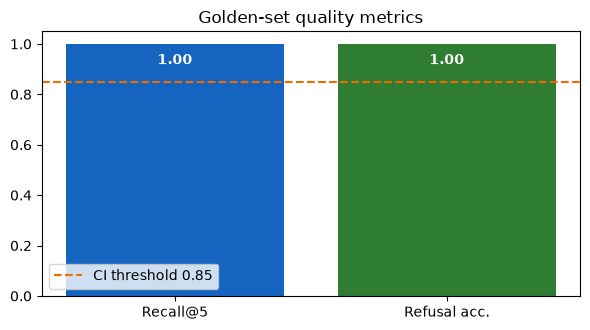

In [27]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(6, 3.4))
bars = ax.bar(['Recall@5', 'Refusal acc.'], [results['recall_at_k'], results['refusal_accuracy']],
              color=['#1565C0', '#2E7D32'])
ax.axhline(0.85, color='#EF6C00', linestyle='--', label='CI threshold 0.85')
ax.set_ylim(0, 1.05); ax.set_title('Golden-set quality metrics'); ax.legend()
for b in bars: ax.text(b.get_x()+b.get_width()/2, b.get_height()-0.08, f'{b.get_height():.2f}',
                       ha='center', color='white', fontweight='bold')
plt.tight_layout(); plt.show()

<div style="background:#E8F5E9;border-left:6px solid #2E7D32;color:#1B5E20;padding:16px 20px;border-radius:10px;margin:6px 0;font-size:15px;line-height:1.6;"><b>✅ What the output means (insight):</b><br>Both metrics sit comfortably above the orange 0.85 CI threshold. If a future change drags either bar below the line, the build fails automatically (Section 13).</div>

<div style="background:linear-gradient(90deg,#1565C0 0%,#7B1FA2 100%);color:#ffffff;padding:16px 22px;border-radius:12px;margin:18px 0 6px 0;"><h2 style="margin:0;color:#ffffff;font-size:24px;">12. &nbsp;NLI faithfulness — is the answer actually supported?</h2></div>

<div style="background:#F3E5F5;border-left:6px solid #8E24AA;color:#4A148C;padding:16px 20px;border-radius:10px;margin:6px 0;font-size:15px;line-height:1.6;"><b>🧠 Concept &amp; theory:</b><br><b>Faithfulness</b> asks: is every claim in the answer actually backed by the retrieved evidence, or did the model drift? We score it <b>without an LLM judge</b> (zero cost) using a <b>Natural Language Inference (NLI)</b> model, which classifies a (premise, hypothesis) pair as <i>entailment / neutral / contradiction</i>. For each sentence of the answer, we check whether any retrieved passage <b>entails</b> it; the score is the mean best-entailment across the answer&rsquo;s sentences.</div>

<div style="background:#FFF3E0;border-left:6px solid #EF6C00;color:#E65100;padding:16px 20px;border-radius:10px;margin:6px 0;font-size:15px;line-height:1.6;"><b>⚠️ Honest note / gotcha:</b><br><b>A real bug we caught (and why validation matters).</b> The first version fed whole 380-token passages as the NLI premise — and it rated a blatant hallucination almost as &ldquo;faithful&rdquo; as a grounded answer (~0.60 vs ~0.62). NLI models are trained on <i>short</i> premises, so long passages made every score mushy. The fix: split both the context and the answer into clean sentences (carefully, without shredding on abbreviations like &ldquo;no.&rdquo; or clause numbers like &ldquo;13.03&rdquo;), then compare sentence-to-sentence. After the fix the metric discriminates sharply — as shown below.</div>

<div style="background:#ECEFF1;border-left:6px solid #607D8B;color:#263238;padding:16px 20px;border-radius:10px;margin:6px 0;font-size:15px;line-height:1.6;"><b>▶️ What this cell does (before running):</b><br>Load the NLI model and score two answers against the SAME retrieved passages: the agent&rsquo;s real grounded answer, and a fabricated one about &ldquo;free airline miles&rdquo;.</div>

In [28]:
from faithfulness import load_nli, faithfulness

nli = load_nli()
passages = [h['text'] for h in agent_result['hits']]
grounded_answer = agent_result['answer']
hallucinated = 'Digital lending apps must offer borrowers free airline miles and a 90-day interest-free holiday on every loan.'

f_good = faithfulness(nli, passages, grounded_answer)
f_bad  = faithfulness(nli, passages, hallucinated)
print('Faithfulness — grounded answer  :', f_good['faithfulness'])
print('Faithfulness — hallucinated one :', f_bad['faithfulness'])

The Transformer `cache_dir` argument is deprecated. Please pass `cache_dir` via `model_kwargs`, `processor_kwargs`, and/or `config_kwargs` instead.


Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 105/105 [00:00<00:00, 6441.36it/s]

Faithfulness — grounded answer  : 0.967
Faithfulness — hallucinated one : 0.008


<div style="background:#E8F5E9;border-left:6px solid #2E7D32;color:#1B5E20;padding:16px 20px;border-radius:10px;margin:6px 0;font-size:15px;line-height:1.6;"><b>✅ What the output means (insight):</b><br>The grounded answer scores <b>~0.97</b>; the fabricated one <b>~0.01</b>. The NLI scorer cleanly separates supported answers from invented ones — an offline, free stand-in for a faithfulness judge, and a metric we can trust because we validated it against a known-bad example.</div>

<div style="background:linear-gradient(90deg,#1565C0 0%,#7B1FA2 100%);color:#ffffff;padding:16px 22px;border-radius:12px;margin:18px 0 6px 0;"><h2 style="margin:0;color:#ffffff;font-size:24px;">13. &nbsp;CI quality gate — automation that guards quality</h2></div>

<div style="background:#F3E5F5;border-left:6px solid #8E24AA;color:#4A148C;padding:16px 20px;border-radius:10px;margin:6px 0;font-size:15px;line-height:1.6;"><b>🧠 Concept &amp; theory:</b><br><b>Continuous Integration (CI)</b> runs checks automatically on every code change. Our <b>quality gate</b> runs the fast, deterministic metrics (retrieval recall + refusal accuracy) and <b>fails the build</b> if either drops below <b>0.85</b>. It lives as a GitHub Actions workflow plus a pytest test, so a regression cannot silently ship.</div>

<div style="background:#ECEFF1;border-left:6px solid #607D8B;color:#263238;padding:16px 20px;border-radius:10px;margin:6px 0;font-size:15px;line-height:1.6;"><b>▶️ What this cell does (before running):</b><br>Show the gate thresholds and the GitHub Actions workflow that enforces them on every push.</div>

In [29]:
gate = (project_paths.REPO_ROOT / 'scripts' / 'quality_gate.py').read_text(encoding='utf-8')
print('Thresholds in the gate:')
for line in gate.splitlines():
    if 'MIN =' in line: print('   ', line.strip())

wf = (project_paths.REPO_ROOT / '.github' / 'workflows' / 'quality-gate.yml').read_text(encoding='utf-8')
print('\nGitHub Actions trigger + gate step:')
print('\n'.join(wf.splitlines()[:12]))

Thresholds in the gate:
    RECALL_AT_5_MIN = 0.85
    REFUSAL_ACCURACY_MIN = 0.85

GitHub Actions trigger + gate step:
name: Grounded Quality Gate

# Runs the golden-set quality gate on every push / PR. If retrieval recall or
# refusal accuracy regress below threshold, the build FAILS.

on:
  push:
    branches: [ main, master ]
  pull_request:
    branches: [ main, master ]
  workflow_dispatch:



<div style="background:#E8F5E9;border-left:6px solid #2E7D32;color:#1B5E20;padding:16px 20px;border-radius:10px;margin:6px 0;font-size:15px;line-height:1.6;"><b>✅ What the output means (insight):</b><br>On every push, GitHub spins up a clean machine, rebuilds the retriever from the committed corpus, runs the golden-set metrics, and turns the build <b>green only if quality holds</b>. This is the difference between &ldquo;it worked on my laptop once&rdquo; and a system whose quality is continuously guaranteed.</div>

<div style="background:linear-gradient(135deg,#1565C0 0%,#6A1B9A 100%);color:#ffffff;padding:34px 30px;border-radius:16px;margin:4px 0;box-shadow:0 6px 18px rgba(106,27,154,0.35);"><h1 style="margin:0;font-size:32px;color:#ffffff;">✅ Grounded — Built, Validated, Defensible</h1><p style="margin:10px 0 0 0;font-size:17px;color:#E3F2FD;">A fully-offline, citation-enforced agentic RAG assistant over real RBI Master Directions — every claim traceable to a page, every metric measured, every choice defensible.</p></div>

<div style="background:#FAFAFA;border-left:6px solid #BDBDBD;color:#212121;padding:16px 20px;border-radius:10px;margin:6px 0;font-size:15px;line-height:1.6;"><b>What we built, end to end:</b><br>① 10 real RBI Master Directions → profiled (720 pages, 1.4M chars, zero scanned files)<br>② 1,252 page-tagged chunks → bge-small embeddings → ChromaDB<br>③ Hybrid retrieval (BM25 + semantic) → cross-encoder re-ranking → page-level citations<br>④ Citation enforcement — answers when evidence is strong, <b>declines when it is not</b><br>⑤ LangGraph agent + local LLM (Qwen2.5-3B, offline, zero cost) writing cited answers<br>⑥ Golden set + retrieval/refusal metrics + NLI faithfulness + a CI quality gate</div>

<div style="background:#E0F2F1;border-left:6px solid #00897B;color:#004D40;padding:16px 20px;border-radius:10px;margin:6px 0;font-size:15px;line-height:1.6;"><b>🎯 Interview prep:</b><br><b>Q: &ldquo;What makes this &lsquo;production-grade&rsquo; and not a toy?&rdquo;</b><br>A: Three things. It <i>refuses</i> rather than hallucinates (citation enforcement, validated on out-of-scope questions). Every answer is <i>traceable</i> to a document and page. And its quality is <i>measured and guarded</i> — a golden set, faithfulness scoring, and a CI gate that fails the build on regression. Plus it runs fully offline at zero cost, so it is reproducible by anyone.</div>

<div style="background:#FFF3E0;border-left:6px solid #EF6C00;color:#E65100;padding:16px 20px;border-radius:10px;margin:6px 0;font-size:15px;line-height:1.6;"><b>⚠️ Honest note / gotcha:</b><br><b>Honest limitations.</b> The corpus is a focused 10-document slice, so the assistant is only knowledgeable within it (by design, it declines outside). The local 3B model is capable but smaller than hosted frontier models. Recall is measured at document level on a small hand-authored set. None of these are hidden — they are the roadmap for a v2.</div>

<div style="background:#E8F5E9;border-left:6px solid #2E7D32;color:#1B5E20;padding:16px 20px;border-radius:10px;margin:6px 0;font-size:15px;line-height:1.6;"><b>✅ What the output means (insight):</b><br><b>This notebook is the full story:</b> real data, real validation at every step, real outputs, and a system whose every result can be defended line-by-line. 🎉</div>